<a href="https://colab.research.google.com/github/Suleymanov23/movie-ratings-polars-analysis/blob/main/movie_ratings_polars_analysis_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

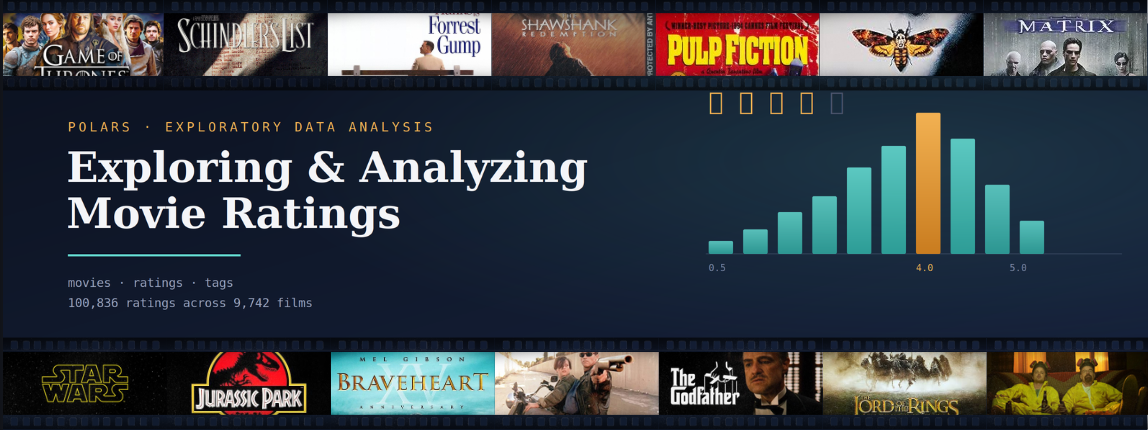

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


This notebook works through a Movie's dataset- three linked tables (`movies`, `ratings`, `tags`)

Plan:
1. Load the three files and know what's in them
2. Cleaning - fix types, deal with missing values and duplicates
3. Work through a set of questions about ratings, genres, movies, users and tags
4. Poke at a few extra questions that came up while doing the above, just because they seemed worth checking

`movie_id` is what ties all three tables together (and `user_id` links `ratings` and `tags`).

In [ ]:
import polars as pl

## Loading the data and inspecting

First I opened each file and see what I am working with, was delimiter and headers were read correctly, did polars wrote the type correctly, and how big echh table is.
`ratings.csv` has over 100k rows, so `.describe()` is more useful here than `.head()` .

In [ ]:
movies = pl.read_csv('/content/drive/MyDrive/polars project/movies.csv')
ratings = pl.read_csv('/content/drive/MyDrive/polars project/ratings.csv')
tags = pl.read_csv('/content/drive/MyDrive/polars project/tags.csv')

print('movies:', movies.shape)
print('ratings:', ratings.shape)
print('tags:', tags.shape)

movies: (9742, 3)
ratings: (100836, 4)
tags: (3683, 4)


In [ ]:
movies.head()

movieId,title,genres
i64,str,str
1,"""Toy Story (1995)""","""Adventure|Animation|Children|C…"
2,"""Jumanji (1995)""","""Adventure|Children|Fantasy"""
3,"""Grumpier Old Men (1995)""","""Comedy|Romance"""
4,"""Waiting to Exhale (1995)""","""Comedy|Drama|Romance"""
5,"""Father of the Bride Part II (1…","""Comedy"""


In [ ]:
movies.schema

Schema([('movieId', Int64), ('title', String), ('genres', String)])

In [ ]:
ratings.head()

userId,movieId,rating,timestamp
i64,i64,f64,i64
1,1,4.0,964982703
1,3,4.0,964981247
1,6,4.0,964982224
1,47,5.0,964983815
1,50,5.0,964982931


In [ ]:
# ratings.csv is large, so .describe() gives a better overview than scrolling through .head()
ratings.describe()

statistic,userId,movieId,rating,timestamp
str,f64,f64,f64,f64
"""count""",100836.0,100836.0,100836.0,100836.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",326.127564,19435.295718,3.501557,1.2059e9
"""std""",182.618491,35530.987199,1.042529,2.1626e8
"""min""",1.0,1.0,0.5,8.28124615e8
"""25%""",177.0,1199.0,3.0,1.0191e9
"""50%""",325.0,2991.0,3.5,1.1861e9
"""75%""",477.0,8121.0,4.0,1.4360e9
"""max""",610.0,193609.0,5.0,1.5378e9


In [ ]:
tags.head()

userId,movieId,tag,timestamp
i64,i64,str,i64
2,60756,"""funny""",1445714994
2,60756,"""Highly quotable""",1445714996
2,60756,"""will ferrell""",1445714992
2,89774,"""Boxing story""",1445715207
2,89774,"""MMA""",1445715200


In [ ]:
tags.schema

Schema([('userId', Int64),
        ('movieId', Int64),
        ('tag', String),
        ('timestamp', Int64)])

All three files read in fine with the default comma separator, no special arguments needed.

One thing I noticed is that the id columns are written as `movieId` / `userId`, which can cause a mistype. So, I'm renaming every such column to lowercase

In [ ]:
movies = movies.rename({'movieId': 'movie_id'})
ratings = ratings.rename({'userId': 'user_id', 'movieId': 'movie_id'})
tags = tags.rename({'userId': 'user_id', 'movieId': 'movie_id'})

movies.columns, ratings.columns, tags.columns

(['movie_id', 'title', 'genres'],
 ['user_id', 'movie_id', 'rating', 'timestamp'],
 ['user_id', 'movie_id', 'tag', 'timestamp'])

## Preprocess the Data

In this part I checked:

1. **Data types** - ids should be intefers, `rating` needs to support float values, `timestamp` is Unix time (integer).
2. **Missing values** - including 'fake' ones, where there exist a placeholder not real value.
3. **Duplicate rows**

### Data types

In [ ]:
movies.dtypes, ratings.dtypes, tags.dtypes

([Int64, String, String],
 [Int64, Int64, Float64, Int64],
 [Int64, Int64, String, Int64])

`movie_id` / `user_id` were already read in as integers, and `timestamp` as an integer, which is what I want. `rating` was read in as `Float64` already because Polars saw float values in the column. Anyway I have nothing to lose if I cast them again (for being comfortoble).

In [ ]:
movies = movies.with_columns(pl.col("movie_id").cast(pl.Int64))
ratings = ratings.with_columns([
    pl.col("user_id").cast(pl.Int64),
    pl.col("movie_id").cast(pl.Int64),
    pl.col("rating").cast(pl.Float64),
    pl.col("timestamp").cast(pl.Int64),
])
tags = tags.with_columns([
    pl.col("user_id").cast(pl.Int64),
    pl.col("movie_id").cast(pl.Int64),
    pl.col("timestamp").cast(pl.Int64),
])

### Missing values

In [ ]:
movies.null_count()

movie_id,title,genres
u32,u32,u32
0,0,0


In [ ]:
ratings.null_count()

user_id,movie_id,rating,timestamp
u32,u32,u32,u32
0,0,0,0


In [ ]:
tags.null_count()

user_id,movie_id,tag,timestamp
u32,u32,u32,u32
0,0,0,0


From results we do not see any null values. No null values is normal for 'ratings' table because the data falls there once user submit a rate.

But İ am suspicious of these results, I thing there can still be nulls, but they have been replaced with stakeholder.

For example, in genres there are a few distinct values if we split them with `|` . We can look at them and see if there is a problematic value

In [ ]:
#To see full output in the code below
pl.Config.set_tbl_rows(25)

polars.config.Config

In [ ]:
movies.select(pl.col("genres").str.split("|").alias("unique_genres")).explode("unique_genres").unique()

unique_genres
str
"""Horror"""
"""Musical"""
"""War"""
"""Documentary"""
"""Western"""
"""Mystery"""
"""Romance"""
"""Drama"""
"""Crime"""


Yes, as I felt there is a hidden null - '(no genres listed)'

In [ ]:
movies = movies.with_columns(pl.when(pl.col('genres') == '(no genres listed)').then(None).otherwise(pl.col('genres')).alias('genres'))

movies.filter(pl.col("genres").is_null()).height

34

I decided to check for other columns that need

- for text columns with thousands of distinct values (`title`, `tag`), looking at every unique value isn't practical, so instead, I check for empty strings,space only, strings, and common placeholder words like "n/a" or "unknown"

- for numeric columns (`rating`, `timestamp`), a hidden missing value can be `0` or `-1`, so `.describe()` / min-max is the useful check

In [ ]:
# tag column
tags.filter(pl.col('tag').str.strip_chars().is_in([''])   |   pl.col('tag').str.to_lowercase().is_in(['n/a', 'na', 'none', 'null', 'unknown', '-']))

user_id,movie_id,tag,timestamp
i64,i64,str,i64


In [ ]:
# title column
movies.filter((pl.col('title').str.strip_chars() == "") |    pl.col('title').str.to_lowercase().is_in(['n/a', 'na', 'none', 'null', 'unknown', '-']))

movie_id,title,genres
i64,str,str


These are clean

In [ ]:
ratings.describe()

statistic,user_id,movie_id,rating,timestamp
str,f64,f64,f64,f64
"""count""",100836.0,100836.0,100836.0,100836.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",326.127564,19435.295718,3.501557,1.2059e9
"""std""",182.618491,35530.987199,1.042529,2.1626e8
"""min""",1.0,1.0,0.5,8.28124615e8
"""25%""",177.0,1199.0,3.0,1.0191e9
"""50%""",325.0,2991.0,3.5,1.1861e9
"""75%""",477.0,8121.0,4.0,1.4360e9
"""max""",610.0,193609.0,5.0,1.5378e9


In [ ]:
tags.describe()

statistic,user_id,movie_id,tag,timestamp
str,f64,f64,str,f64
"""count""",3683.0,3683.0,"""3683""",3683.0
"""null_count""",0.0,0.0,"""0""",0.0
"""mean""",431.149335,27252.013576,null,1.3200e9
"""std""",158.472553,43490.558803,null,1.7210e8
"""min""",2.0,1.0,"""""artsy""""",1.1372e9
"""25%""",424.0,1263.0,null,1.1375e9
"""50%""",474.0,4454.0,null,1.2698e9
"""75%""",477.0,39292.0,null,1.4985e9
"""max""",610.0,193565.0,"""zombies""",1.5371e9


From min and max values we can say hese are also clean. Only genres column had fake missing values

### Duplicate values

In [ ]:
print('Duplicate rows in movies:', movies.is_duplicated().sum())
print('Duplicate rows in ratings:', ratings.is_duplicated().sum())
print('Duplicate rows in tags:', tags.is_duplicated().sum())

Duplicate rows in movies: 0
Duplicate rows in ratings: 0
Duplicate rows in tags: 0


In [ ]:
# Is movie_id actually unique in movies?
dub_movie_ids = movies.select(pl.col('movie_id').is_duplicated().sum())
print('Duplicate movie_id values in movies:', dub_movie_ids)

Duplicate movie_id values in movies: shape: (1, 1)
┌──────────┐
│ movie_id │
│ ---      │
│ u32      │
╞══════════╡
│ 0        │
└──────────┘


In [ ]:
# Does any ['user_id', 'movie_id'] pair appear more than once in ratings?
dub_rating_pairs =ratings.group_by(['user_id', 'movie_id']).agg(pl.len().alias('n')) .filter(pl.col('n') > 1)
print("Duplicate ['user_id', 'movie_id'] pairs in ratings:", dub_rating_pairs.height)

Duplicate ['user_id', 'movie_id'] pairs in ratings: 0


In [ ]:
# Same user, same movie, same tag text repeated at a different time?
dub_tag_events = tags.group_by(['user_id', 'movie_id', 'tag']).agg(pl.len().alias('n')).filter(pl.col('n') > 1)

print("Duplicate (user_id, movie_id, tag) pairs, ignoring timestamp:", dub_tag_events.height)

Duplicate (user_id, movie_id, tag) pairs, ignoring timestamp: 0


**Quick recap of what got cleaned:** Small column names everywhere, ids as `Int64`, `rating` as `Float64`, `timestamp` as `Int64`, the `"(no genres listed)"` placeholder turned into a real null, `ratings` basically didn't need any cleaning except the type casts whchih makes sense,since it's generated automatically whenever someone submits a rating.

One more thing I want to do is spliting genres to list, because I will need them in the future and I do not want to call it every time

In [ ]:
movies = movies.with_columns(pl.col('genres').str.split('|').alias('genres_list'))
movies.head()

movie_id,title,genres,genres_list
i64,str,str,list[str]
1,"""Toy Story (1995)""","""Adventure|Animation|Children|C…","[""Adventure"", ""Animation"", … ""Fantasy""]"
2,"""Jumanji (1995)""","""Adventure|Children|Fantasy""","[""Adventure"", ""Children"", ""Fantasy""]"
3,"""Grumpier Old Men (1995)""","""Comedy|Romance""","[""Comedy"", ""Romance""]"
4,"""Waiting to Exhale (1995)""","""Comedy|Drama|Romance""","[""Comedy"", ""Drama"", ""Romance""]"
5,"""Father of the Bride Part II (1…","""Comedy""","[""Comedy""]"


## Analysis

### Part 1

**1.1 - Checking the rating scale.** Ratings should fall between 0.5 and 5.0.

In [ ]:
min_max = ratings.select([pl.col('rating').min().alias('min_rating'),
                          pl.col('rating').max().alias('max_rating'),])
print(min_max)

shape: (1, 2)
┌────────────┬────────────┐
│ min_rating ┆ max_rating │
│ ---        ┆ ---        │
│ f64        ┆ f64        │
╞════════════╪════════════╡
│ 0.5        ┆ 5.0        │
└────────────┴────────────┘


**1.2 - Count of ratings per score.**

In [ ]:
rating_counts = ratings.group_by('rating').agg(pl.len().alias('count')).sort('rating')

print(rating_counts)

shape: (10, 2)
┌────────┬───────┐
│ rating ┆ count │
│ ---    ┆ ---   │
│ f64    ┆ u32   │
╞════════╪═══════╡
│ 0.5    ┆ 1370  │
│ 1.0    ┆ 2811  │
│ 1.5    ┆ 1791  │
│ 2.0    ┆ 7551  │
│ 2.5    ┆ 5550  │
│ 3.0    ┆ 20047 │
│ 3.5    ┆ 13136 │
│ 4.0    ┆ 26818 │
│ 4.5    ┆ 8551  │
│ 5.0    ┆ 13211 │
└────────┴───────┘


**1.3 - Average rating per genre.** Each movie can belong to several genres, so `genres_list` is exploded into one row per (movie, genre) pair before joining to ratings. If I do otherwise, a movie's ratings would only count whichever genre listed first.

In [ ]:
movie_genres = movies.select(['movie_id', 'genres_list']).explode('genres_list').rename({'genres_list': 'unique_genres'})
merged_table = movie_genres.join(ratings, on = ['movie_id'], how = 'left')

avg_rating = merged_table.group_by('unique_genres').agg(pl.col('rating').mean().alias('avg_rating')).sort('avg_rating', descending = True)

print(avg_rating)

shape: (20, 2)
┌───────────────┬────────────┐
│ unique_genres ┆ avg_rating │
│ ---           ┆ ---        │
│ str           ┆ f64        │
╞═══════════════╪════════════╡
│ Film-Noir     ┆ 3.920115   │
│ War           ┆ 3.808294   │
│ Documentary   ┆ 3.797785   │
│ Crime         ┆ 3.658294   │
│ Drama         ┆ 3.656184   │
│ Mystery       ┆ 3.63246    │
│ Animation     ┆ 3.629937   │
│ IMAX          ┆ 3.618335   │
│ Western       ┆ 3.583938   │
│ Musical       ┆ 3.563678   │
│ Adventure     ┆ 3.508609   │
│ Romance       ┆ 3.506511   │
│ Thriller      ┆ 3.493706   │
│ Fantasy       ┆ 3.491001   │
│ null          ┆ 3.489362   │
│ Sci-Fi        ┆ 3.455721   │
│ Action        ┆ 3.447984   │
│ Children      ┆ 3.412956   │
│ Comedy        ┆ 3.384721   │
│ Horror        ┆ 3.258195   │
└───────────────┴────────────┘


**1.4- Ratings per user: min, max, mean.**

In [ ]:
ratings_per_user = ratings.group_by('user_id').agg(pl.len().alias('ratings_count'))

ratings_per_user.select([
    pl.col('ratings_count').min().alias('min_ratings_count'),
    pl.col('ratings_count').max().alias('max_ratings_count'),
    pl.col('ratings_count').mean().alias('mean_ratings_count')])

min_ratings_count,max_ratings_count,mean_ratings_count
u32,u32,f64
20,2698,165.304918


**1.5 - Top 5 most active users.**

In [ ]:
top5_users = ratings_per_user.sort('ratings_count', descending=True).head(5)
print(top5_users)

shape: (5, 2)
┌─────────┬───────────────┐
│ user_id ┆ ratings_count │
│ ---     ┆ ---           │
│ i64     ┆ u32           │
╞═════════╪═══════════════╡
│ 414     ┆ 2698          │
│ 599     ┆ 2478          │
│ 474     ┆ 2108          │
│ 448     ┆ 1864          │
│ 274     ┆ 1346          │
└─────────┴───────────────┘


### Part 2

**2.1 - Average rating: top 10 most-rated movies vs. bottom 10 (min 5 ratings).** This is essentially asking whether popularity and quality are related, do more rated movies score higher or lower on average than niche movies that still cleared a minimum rating count?

In [ ]:
movie_scores = merged_table.group_by('movie_id').agg([pl.len().alias('rating_counts'), pl.col('rating').mean().alias('avg_rating')])

top_10 = movie_scores.sort('rating_counts', descending = True).head(10)

bottom_10 = movie_scores.filter(pl.col('rating_counts')>=5).sort('rating_counts', descending = True).tail(10)

print('Top 10 most rated movies:', top_10)
print('Bottom 10 least rated movies (having least 5 ratings)', bottom_10)

print('Average rating for top 10 most rated movies:', top_10['avg_rating'].mean())
print('Average rating for bottom 10 least rated movies:', bottom_10['avg_rating'].mean())

Top 10 most rated movies: shape: (10, 3)
┌──────────┬───────────────┬────────────┐
│ movie_id ┆ rating_counts ┆ avg_rating │
│ ---      ┆ ---           ┆ ---        │
│ i64      ┆ u32           ┆ f64        │
╞══════════╪═══════════════╪════════════╡
│ 356      ┆ 1316          ┆ 4.164134   │
│ 296      ┆ 1228          ┆ 4.197068   │
│ 1        ┆ 1075          ┆ 3.92093    │
│ 364      ┆ 1032          ┆ 3.94186    │
│ 4306     ┆ 1020          ┆ 3.867647   │
│ 79132    ┆ 1001          ┆ 4.066434   │
│ 480      ┆ 952           ┆ 3.75       │
│ 588      ┆ 915           ┆ 3.79235    │
│ 380      ┆ 890           ┆ 3.497191   │
│ 595      ┆ 876           ┆ 3.770548   │
└──────────┴───────────────┴────────────┘
Bottom 10 least rated movies (having least 5 ratings) shape: (10, 3)
┌──────────┬───────────────┬────────────┐
│ movie_id ┆ rating_counts ┆ avg_rating │
│ ---      ┆ ---           ┆ ---        │
│ i64      ┆ u32           ┆ f64        │
╞══════════╪═══════════════╪════════════╡
│ 4021  

**2.2 - Distribution of number of ratings per movie.** How many movies received exactly 1 rating, exactly 2, exactly 3, and so on.

In [ ]:
ratings_per_movie = ratings.group_by('movie_id').agg(pl.len().alias('rating_counts'))

rating_distribution = ratings_per_movie.group_by('rating_counts').agg(pl.len().alias('movie_counts')).sort('rating_counts')
print(rating_distribution)

shape: (177, 2)
┌───────────────┬──────────────┐
│ rating_counts ┆ movie_counts │
│ ---           ┆ ---          │
│ u32           ┆ u32          │
╞═══════════════╪══════════════╡
│ 1             ┆ 3446         │
│ 2             ┆ 1298         │
│ 3             ┆ 800          │
│ 4             ┆ 530          │
│ 5             ┆ 382          │
│ 6             ┆ 319          │
│ 7             ┆ 278          │
│ 8             ┆ 230          │
│ 9             ┆ 172          │
│ 10            ┆ 148          │
│ 11            ┆ 154          │
│ 12            ┆ 118          │
│ 13            ┆ 105          │
│ …             ┆ …            │
│ 215           ┆ 1            │
│ 218           ┆ 1            │
│ 220           ┆ 1            │
│ 224           ┆ 1            │
│ 237           ┆ 1            │
│ 238           ┆ 1            │
│ 251           ┆ 1            │
│ 278           ┆ 1            │
│ 279           ┆ 1            │
│ 307           ┆ 1            │
│ 317           ┆ 1        

**2.3- Top 20 most frequently rated movies.**

In [ ]:
top_20 =ratings_per_movie.join(movies.select(['movie_id','title']), on = 'movie_id' , how='left').select(['movie_id','title','rating_counts']).sort('rating_counts', descending = True).head(20)
print(top_20)

shape: (20, 3)
┌──────────┬─────────────────────────────────┬───────────────┐
│ movie_id ┆ title                           ┆ rating_counts │
│ ---      ┆ ---                             ┆ ---           │
│ i64      ┆ str                             ┆ u32           │
╞══════════╪═════════════════════════════════╪═══════════════╡
│ 356      ┆ Forrest Gump (1994)             ┆ 329           │
│ 318      ┆ Shawshank Redemption, The (199… ┆ 317           │
│ 296      ┆ Pulp Fiction (1994)             ┆ 307           │
│ 593      ┆ Silence of the Lambs, The (199… ┆ 279           │
│ 2571     ┆ Matrix, The (1999)              ┆ 278           │
│ 260      ┆ Star Wars: Episode IV - A New … ┆ 251           │
│ 480      ┆ Jurassic Park (1993)            ┆ 238           │
│ 110      ┆ Braveheart (1995)               ┆ 237           │
│ 589      ┆ Terminator 2: Judgment Day (19… ┆ 224           │
│ 527      ┆ Schindler's List (1993)         ┆ 220           │
│ 2959     ┆ Fight Club (1999)          

** 2.4- Unique genre count + top 10 most common genres.**

In [ ]:
unique_genres = movie_genres.select('unique_genres').unique().height
print('Number_of_unique_genres:', unique_genres)

top_10_genres= movie_genres.group_by('unique_genres').agg(pl.len().alias('movie_counts')).sort('movie_counts', descending = True).head(10)
print(top_10_genres)

Number_of_unique_genres: 20
shape: (10, 2)
┌───────────────┬──────────────┐
│ unique_genres ┆ movie_counts │
│ ---           ┆ ---          │
│ str           ┆ u32          │
╞═══════════════╪══════════════╡
│ Drama         ┆ 4361         │
│ Comedy        ┆ 3756         │
│ Thriller      ┆ 1894         │
│ Action        ┆ 1828         │
│ Romance       ┆ 1596         │
│ Adventure     ┆ 1263         │
│ Crime         ┆ 1199         │
│ Sci-Fi        ┆ 980          │
│ Horror        ┆ 978          │
│ Fantasy       ┆ 779          │
└───────────────┴──────────────┘


**2.5-Movie count and average rating per genre, sorted.**

In [ ]:
genre_movie_ratings = ratings.join(movie_genres, on='movie_id', how='inner').group_by('unique_genres').agg(
      [pl.col('movie_id').n_unique().alias('movies_counts'),
      pl.col('rating').mean().alias('avg_rating')]).sort('avg_rating', descending=True)
print(genre_movie_ratings)

shape: (20, 3)
┌───────────────┬───────────────┬────────────┐
│ unique_genres ┆ movies_counts ┆ avg_rating │
│ ---           ┆ ---           ┆ ---        │
│ str           ┆ u32           ┆ f64        │
╞═══════════════╪═══════════════╪════════════╡
│ Film-Noir     ┆ 85            ┆ 3.920115   │
│ War           ┆ 381           ┆ 3.808294   │
│ Documentary   ┆ 438           ┆ 3.797785   │
│ Crime         ┆ 1196          ┆ 3.658294   │
│ Drama         ┆ 4349          ┆ 3.656184   │
│ Mystery       ┆ 573           ┆ 3.63246    │
│ Animation     ┆ 610           ┆ 3.629937   │
│ IMAX          ┆ 158           ┆ 3.618335   │
│ Western       ┆ 167           ┆ 3.583938   │
│ Musical       ┆ 333           ┆ 3.563678   │
│ Adventure     ┆ 1262          ┆ 3.508609   │
│ Romance       ┆ 1591          ┆ 3.506511   │
│ Thriller      ┆ 1889          ┆ 3.493706   │
│ Fantasy       ┆ 778           ┆ 3.491001   │
│ null          ┆ 34            ┆ 3.489362   │
│ Sci-Fi        ┆ 980           ┆ 3.455721   

### Part 3

**3.1-Tags per movie: average, min, max.**

In [ ]:
tags_per_movie = tags.group_by('movie_id').agg(pl.len().alias('tag_counts'))

tags_per_movie.select([ pl.col('tag_counts').mean().alias('avg_tags_per_movie'),
                       pl.col('tag_counts').min().alias('min_tags_per_movie'),
                      pl.col('tag_counts').max().alias('max_tags_per_movie')])

avg_tags_per_movie,min_tags_per_movie,max_tags_per_movie
f64,u32,u32
2.342875,1,181


This is calculated only over movies that have at least one tag - `tags_per_movie` is built from `tags.group_by("movie_id")`, so movies with zero tags simply don't appear in it. Including every movie (with a left join and filling missings with 0) would pull the average down and answer a slightly different.

**3.2 - Top 20 most frequently applied tags.** Users can write whatever they want for tags, so the same idea often gets typed with different capitalization (`"funny"` vs `"Funny"`). Lowercasing before counting will be useful

In [ ]:
top_20_tags = tags.with_columns(pl.col('tag').str.to_lowercase().alias('lower_tag')).group_by('lower_tag').agg(pl.len().alias('count')).sort("count", descending=True).head(20)
print(top_20_tags)

shape: (20, 2)
┌────────────────────┬───────┐
│ lower_tag          ┆ count │
│ ---                ┆ ---   │
│ str                ┆ u32   │
╞════════════════════╪═══════╡
│ in netflix queue   ┆ 131   │
│ atmospheric        ┆ 41    │
│ thought-provoking  ┆ 24    │
│ superhero          ┆ 24    │
│ surreal            ┆ 24    │
│ funny              ┆ 24    │
│ disney             ┆ 23    │
│ sci-fi             ┆ 23    │
│ religion           ┆ 22    │
│ quirky             ┆ 22    │
│ dark comedy        ┆ 21    │
│ psychology         ┆ 21    │
│ suspense           ┆ 21    │
│ visually appealing ┆ 20    │
│ twist ending       ┆ 20    │
│ comedy             ┆ 19    │
│ crime              ┆ 19    │
│ politics           ┆ 19    │
│ music              ┆ 17    │
│ high school        ┆ 16    │
└────────────────────┴───────┘


**3.3- Proportion of "high" ratings (>= 4) per movie, for movies with at least 5 ratings.**

In [ ]:
merged_table = movies.join(ratings, on ='movie_id', how = 'left')

In [ ]:
proportion =(
merged_table.with_columns((pl.col('rating')>=4).alias('high_rating')).group_by('movie_id').agg([pl.col('title').alias('title'),
                                                                                                pl.len().alias('rating_counts'),
                                                                                                pl.col('high_rating').mean().alias('high_rating_proportion')])
.filter(pl.col('rating_counts') >= 5)
.select(['movie_id', 'title', 'high_rating_proportion'])
.sort('high_rating_proportion', descending=True)
)

print(proportion)

shape: (3_650, 3)
┌──────────┬─────────────────────────────────┬────────────────────────┐
│ movie_id ┆ title                           ┆ high_rating_proportion │
│ ---      ┆ ---                             ┆ ---                    │
│ i64      ┆ list[str]                       ┆ f64                    │
╞══════════╪═════════════════════════════════╪════════════════════════╡
│ 6104     ┆ ["Monty Python Live at the Hol… ┆ 1.0                    │
│ 177593   ┆ ["Three Billboards Outside Ebb… ┆ 1.0                    │
│ 2940     ┆ ["Gilda (1946)", "Gilda (1946)… ┆ 1.0                    │
│ 1192     ┆ ["Paris Is Burning (1990)", "P… ┆ 1.0                    │
│ 2239     ┆ ["Swept Away (Travolti da un i… ┆ 1.0                    │
│ 7983     ┆ ["Broadway Danny Rose (1984)",… ┆ 1.0                    │
│ 103688   ┆ ["Conjuring, The (2013)", "Con… ┆ 1.0                    │
│ 3341     ┆ ["Born Yesterday (1950)", "Bor… ┆ 1.0                    │
│ 27156    ┆ ["Neon Genesis Evangelion: The… ┆

**3.4- Proportion of re-ratings per user (top 10).** A "re-rating" here means a user rating the *same* movie more than once. The proportion is: (ratings after the first, for movies the user rated more than once) / (total ratings by that user).

In [ ]:
user_rate_times = ratings.group_by(['user_id','movie_id']).agg(pl.len().alias('times_rated'))

result = (user_rate_times.group_by('user_id').agg([pl.col('times_rated').sum().alias('total_ratings'),
                                                  (pl.col('times_rated') - 1).sum().alias('re_rating_counts'),])
.with_columns((pl.col('re_rating_counts') / pl.col('total_ratings')).alias('re_rating_proportion'))
.sort('re_rating_proportion', descending=True)
)
print(result.head(10))

shape: (10, 4)
┌─────────┬───────────────┬──────────────────┬──────────────────────┐
│ user_id ┆ total_ratings ┆ re_rating_counts ┆ re_rating_proportion │
│ ---     ┆ ---           ┆ ---              ┆ ---                  │
│ i64     ┆ u32           ┆ u32              ┆ f64                  │
╞═════════╪═══════════════╪══════════════════╪══════════════════════╡
│ 37      ┆ 21            ┆ 0                ┆ 0.0                  │
│ 540     ┆ 42            ┆ 0                ┆ 0.0                  │
│ 516     ┆ 26            ┆ 0                ┆ 0.0                  │
│ 206     ┆ 25            ┆ 0                ┆ 0.0                  │
│ 9       ┆ 46            ┆ 0                ┆ 0.0                  │
│ 191     ┆ 85            ┆ 0                ┆ 0.0                  │
│ 272     ┆ 31            ┆ 0                ┆ 0.0                  │
│ 445     ┆ 77            ┆ 0                ┆ 0.0                  │
│ 269     ┆ 29            ┆ 0                ┆ 0.0                  │
│ 4  

**Note:** in this dataset, `(user_id, movie_id)` is expected to be unique- a real re-rating would normally overwrite the old row rather than add a new one.If `re_ratings` comes back as 0 for every user, that confirms there are no duplicate `(user_id, movie_id)` pairs in this dataset. The calculation is kept such that it would still work correctly once users submit multiple ratings over time.

**3.5- Top 20 movies by average rating (min 10 ratings).**

In [ ]:
top20_highest_rated = (ratings.group_by('movie_id').agg([pl.len().alias('rating_counts'),
                                                         pl.col('rating').mean().alias('avg_rating'),])
.filter(pl.col('rating_counts') >= 10)
.join(movies.select(['movie_id', 'title']), on='movie_id', how='left')
.select(['movie_id', 'title', 'avg_rating'])
.sort('avg_rating', descending=True).head(20)
)
print(top20_highest_rated)

shape: (20, 3)
┌──────────┬─────────────────────────────────┬────────────┐
│ movie_id ┆ title                           ┆ avg_rating │
│ ---      ┆ ---                             ┆ ---        │
│ i64      ┆ str                             ┆ f64        │
╞══════════╪═════════════════════════════════╪════════════╡
│ 1041     ┆ Secrets & Lies (1996)           ┆ 4.590909   │
│ 3451     ┆ Guess Who's Coming to Dinner (… ┆ 4.545455   │
│ 1178     ┆ Paths of Glory (1957)           ┆ 4.541667   │
│ 1104     ┆ Streetcar Named Desire, A (195… ┆ 4.475      │
│ 2360     ┆ Celebration, The (Festen) (199… ┆ 4.458333   │
│ 1217     ┆ Ran (1985)                      ┆ 4.433333   │
│ 318      ┆ Shawshank Redemption, The (199… ┆ 4.429022   │
│ 951      ┆ His Girl Friday (1940)          ┆ 4.392857   │
│ 1927     ┆ All Quiet on the Western Front… ┆ 4.35       │
│ 3468     ┆ Hustler, The (1961)             ┆ 4.333333   │
│ 922      ┆ Sunset Blvd. (a.k.a. Sunset Bo… ┆ 4.333333   │
│ 3435     ┆ Double Indem

**3.6- Correlation between a movie's number of ratings and its average rating.**

In [ ]:
correlation = movie_scores.select(pl.corr('rating_counts', 'avg_rating')).item()
print('Correlation between number of ratings and average rating:', correlation)

Correlation between number of ratings and average rating: 0.11245427235625337


A correlation of 0.11 is weak but positive meaning movies with more ratings tend to have slightly higher average ratings, but the relationship is too weak to call popularity a real driver of rating quality

## Additional Exploration

### 4.1 - Extract year from the title

Movie titles ends with a year in pharanteses. Taking that part out as its own column opens time dimension for the analysis (ratings by decade, genre trends over time and etc.) that was not available from the the first columns alone.

In [ ]:
movies = movies.with_columns(pl.col('title').str.extract(r'\((\d{4})\)\s*$', 1).cast(pl.Int32).alias('year'))
movies.select(['movie_id', 'title', 'year']).head()

movie_id,title,year
i64,str,i32
1,"""Toy Story (1995)""",1995
2,"""Jumanji (1995)""",1995
3,"""Grumpier Old Men (1995)""",1995
4,"""Waiting to Exhale (1995)""",1995
5,"""Father of the Bride Part II (1…",1995


### 4.2-Average rating by release decade

With `year`, movies can be grouped into decades to see whether older or newer films tend to be rated higher.

In [ ]:
ratings_with_year = ratings.join(movies.select(['movie_id', 'year']), on='movie_id', how='left')

rating_by_decade = (ratings_with_year.filter(pl.col('year').is_not_null()).with_columns(((pl.col('year') // 10) * 10).alias('decade')).group_by('decade').agg([
    pl.len().alias('rating_counts'),
    pl.col('rating').mean().alias('avg_rating')])
.sort('decade')
)
print(rating_by_decade)

shape: (12, 3)
┌────────┬───────────────┬────────────┐
│ decade ┆ rating_counts ┆ avg_rating │
│ ---    ┆ ---           ┆ ---        │
│ i32    ┆ u32           ┆ f64        │
╞════════╪═══════════════╪════════════╡
│ 1900   ┆ 8             ┆ 3.3125     │
│ 1910   ┆ 8             ┆ 3.3125     │
│ 1920   ┆ 125           ┆ 3.74       │
│ 1930   ┆ 687           ┆ 3.733624   │
│ 1940   ┆ 1101          ┆ 3.870572   │
│ 1950   ┆ 1784          ┆ 3.845011   │
│ 1960   ┆ 2858          ┆ 3.808083   │
│ 1970   ┆ 4995          ┆ 3.775676   │
│ 1980   ┆ 12912         ┆ 3.518355   │
│ 1990   ┆ 37087         ┆ 3.434613   │
│ 2000   ┆ 29766         ┆ 3.46575    │
│ 2010   ┆ 9487          ┆ 3.488774   │
└────────┴───────────────┴────────────┘


Most older decades score noticeably higher on average films from the 1940s and 1950s is around 3.85, while 1990s/2000s decreases to verage closer to 3.45.
But rating counts is also important: 1990s or 1910s films has only 8 ratings, in 1920s and 1960s is between 100 and 3000, while 1990s film has tens of thousands. So üe can not say 'movies used to be better' , it is more likely a mix of small sample selection and nostalgia than a real quality difference across eras.

### 4.3- Highest rating disagreement, standart deviation difference

Only the average rating can hide a lot (as above example), a movie can average 3.0 either because everyone agrees it's around 3, or because opinion is split between people who love it and people who hate it (2 and 4 for example). Standard deviation of the rating shows that case: movies with at least 20 ratings and the highest rating spread are the most polarizing titles in the dataset.

In [ ]:
controversial_movies = (ratings.group_by("movie_id").agg([
    pl.len().alias('rating_counts'),
    pl.col('rating').mean().alias('avg_rating'),
    pl.col('rating').std().alias('rating_std'),])
.filter(pl.col('rating_counts') >= 20)
.join(movies.select(['movie_id', 'title']), on='movie_id', how='left')
.select(['movie_id', 'title', 'rating_counts', 'avg_rating', 'rating_std'])
.sort('rating_std', descending=True)
.head(15)
)
print(controversial_movies)

shape: (15, 5)
┌──────────┬─────────────────────────────────┬───────────────┬────────────┬────────────┐
│ movie_id ┆ title                           ┆ rating_counts ┆ avg_rating ┆ rating_std │
│ ---      ┆ ---                             ┆ ---           ┆ ---        ┆ ---        │
│ i64      ┆ str                             ┆ u32           ┆ f64        ┆ f64        │
╞══════════╪═════════════════════════════════╪═══════════════╪════════════╪════════════╡
│ 2427     ┆ Thin Red Line, The (1998)       ┆ 35            ┆ 3.3        ┆ 1.415253   │
│ 737      ┆ Barb Wire (1996)                ┆ 20            ┆ 2.65       ┆ 1.396424   │
│ 2710     ┆ Blair Witch Project, The (1999… ┆ 64            ┆ 2.796875   ┆ 1.373556   │
│ 2953     ┆ Home Alone 2: Lost in New York… ┆ 31            ┆ 2.516129   ┆ 1.363108   │
│ 91658    ┆ Girl with the Dragon Tattoo, T… ┆ 42            ┆ 3.488095   ┆ 1.327422   │
│ 6888     ┆ Scary Movie 3 (2003)            ┆ 20            ┆ 2.275      ┆ 1.312641   │
│ 2384

### 4.4 Do movies with more tags get more ratings?

In [ ]:
engagement = tags_per_movie.join(ratings.group_by('movie_id').agg(pl.len().alias('rating_counts')), on='movie_id', how='inner')

corr_tags_ratings = engagement.select(pl.corr('tag_counts', 'rating_counts')).item()
print('Correlation between number of tags and number of ratings', corr_tags_ratings)

Correlation between number of tags and number of ratings 0.322022761524925


## Wrap-up

Working through this dataset end-to-end, from three raw CSVs to a set of joined, cleaned, and aggregated tables,  ended up covering pretty much every core Polars operation: type-safe loading, catching both obvious and hidden missing values, checking for duplicates at the row level and the key level, exploding list columns, multi_table joins, group_by aggregations, and a few derived features (year, decade, genre count) that opened up angles the raw columns didn't have on their own.

A couple of things stood out: popularity and rating quality are only weakly linked (correlation of just 0.11), and while older decades average higher ratings, that's more likely survivorship bias, only the classics from those eras are still being watched than movies actually getting worse over time. The dataset itself was also unusually clean, with no duplicates at any level once actually checked for.